# TP4 AA1

**Duran Juan Jose**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido
  - Una segunda vez para postear su entrega
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.


#**Tarea: Aplicación de Regresión Lineal y Análisis de Importancia de Variables**  
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=  
   - Requisitos:  
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).  
     - Idealmente, que las features tengan distintas escalas o unidades ( no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

**Informacion sobre el dataset**

El dataset contiene infomacion sobre la industria textil y sus procesos manuales de fabricacion y la performance de los empleados para hacer frente a la demanda creciente de textiles y su envio a las diferetnes partes del mundo.




**Variables**

- date:	fecha (MM-DD-YYYY)

- day: dia de la semana

- quarter: una parte del mes, dividido en cuatro partes.

- department: departamente asociado

- team_no:	numero de equipo

- no_of_workers: numero de trabajadores por equipo

- no_of_style_change: cantidad de cambios de estilo realizado a un producto en particular

- targeted_productivity: objetivo de productividad determinado por la autoridad de cada equipo

- smv: Standard Minute Value (Valor Estandar por Minuto), tiempo asignado para una tarea

- wip: Work in progress (Trabajo en Progreso), incluye el numero de productos sin finalizar

- over_time: cantidad de horas extras para cada equipo en minutos

- incentive: insentivos financieros que permiten o motivan un curso de accion particular

- idle_time: cantidad de tiempo en la cual se ve interrumpida la produccion por diversas razones

- idle_men:	numero de trabajadores inactivos cuando se interrumpe la produccion

- actual_productivity: porcentaje de la produccion realizado por los trabajadores. Rango entre 0 y 1.

*actual_productivity es la variable target, las otras 14 variables corresponden a las variables features.

In [14]:
# Descargamos el earchivo .zip desde la url donde se encuentra alojado

!wget https://archive.ics.uci.edu/static/public/597/productivity+prediction+of+garment+employees.zip

--2026-06-24 20:22:49--  https://archive.ics.uci.edu/static/public/597/productivity+prediction+of+garment+employees.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘productivity+prediction+of+garment+employees.zip.1’

productivity+predic     [ <=>                ]  92.87K  --.-KB/s    in 0.1s    

2026-06-24 20:22:49 (948 KB/s) - ‘productivity+prediction+of+garment+employees.zip.1’ saved [95095]



In [15]:
# Descomprimimos el archivo .zip

!unzip productivity+prediction+of+garment+employees.zip

Archive:  productivity+prediction+of+garment+employees.zip
replace garments_worker_productivity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
 extracting: garments_worker_productivity.csv  


In [16]:
# Se guarda el archivo .csv extraido desde el .zip descromprimido en una
# variable "path" que luego usaremos para el analisis

path = '/content/garments_worker_productivity.csv'


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?  


## Resolución:

In [17]:
# Se importan las libreria necesarias para el analisis

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

**EDA (Analisis Exploratorio de Datos)**

In [18]:
# Se lee el Dataset que se ecuentra en la variable "path" definida al principio
# del documento y luego se transforma en un DataFrame de Pandas, que se
# utilizara para hacer el analisis

data = pd.read_csv(path)
df = pd.DataFrame(data)

In [19]:
# Se define una funcion "eda" que mostrara el analisis exploratorio de los
# datos del Dataset

def eda(df):
  print('Primeras 5 filas del Dataset:\n')
  display(df.head())
  print('\n')
  print('*' * df.shape[0])
  print('\nTamaño del dataset:\n')
  print(f'Cantidad de filas: {df.shape[0]}')
  print(f'Cantidad de columnas: {df.shape[1]}')
  print('\n')
  print('*' * df.shape[0])
  print('\nInformacion sobre los datos del Dataset:\n')
  display(df.info())
  print('\n')
  print('*' * df.shape[0])
  print('\nComprobacion de nulos:\n')
  display(df.isnull().sum())
  print('\n')
  print('*' * df.shape[0])
  print('\nAnalisis descriptivo del Dataset:\n')
  display(df.describe())

In [20]:
# Llamado a la funcion "eda" utilizando como parametro el DataFrame creado con
# anterioridad

eda(df)

Primeras 5 filas del Dataset:



,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382




**************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

None



**************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0




**************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


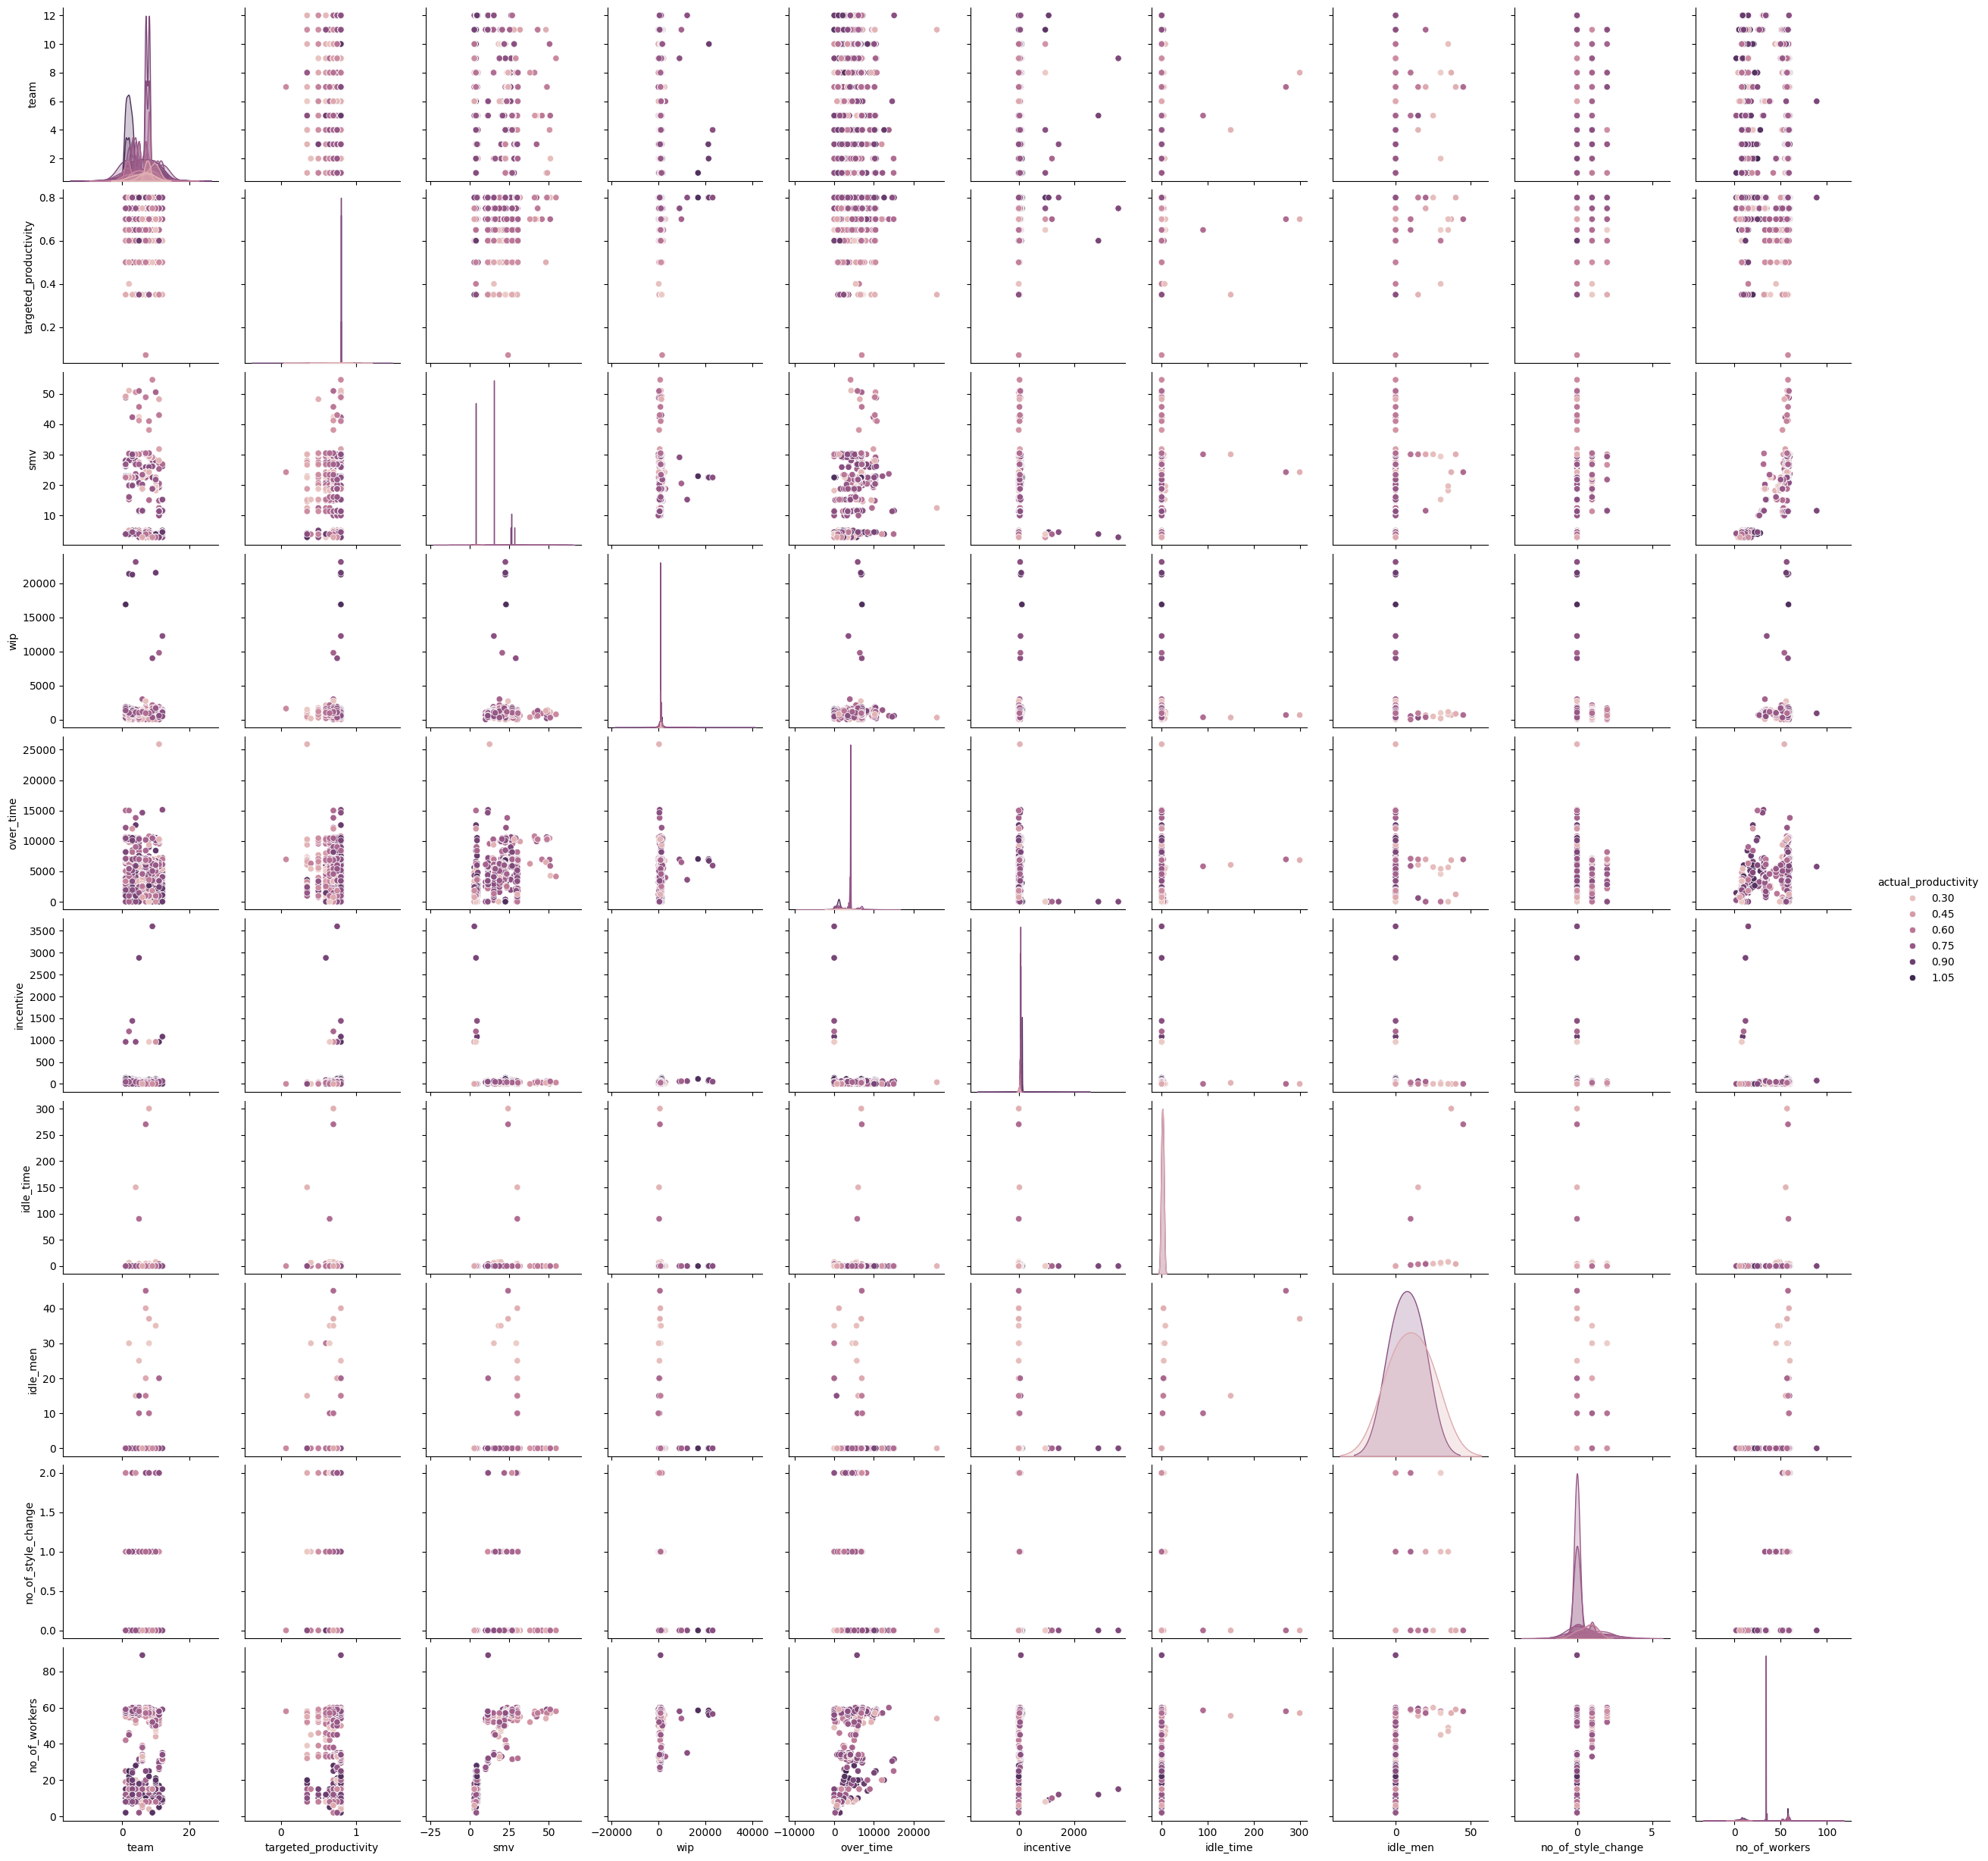

In [21]:
sns.pairplot(df, hue='actual_productivity')
plt.show()

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.  
   - Dividan en train/test (70-30 o 80-20).  

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

Se va a limpiar el dataframe antes de escalarlo y entrenar el modelo.

-Se van a elimnar las variables 'date', 'department', 'quarter', 'day' y 'team' ya que no parecieran tener influencia real sobre la variable target.

-Las variables 'idle_time', 'idle_men' y 'no_of_style_change', no muestran datos significativos en el analisis descriptivo, por lo cual se aminora su influencia en el target.

-'targeted_productivity', es una variable que muestra la productividad estimada por el equipo de trabajo, por lo cual no tiene influencia en el target, ya que, sea cual sea ese numero, no influye en el resultado final, se podria poner o no, que el resultado final seria el mismo.

-La variable 'wip', muestra casi el 50% de datos nulos, teniendo en cuenta de que marca la cantidad de productos que estan en proceso, cabria de esperar que no influya en el resultado final que se busca predecir, por lo tanto, se eliminara del modelo.

In [23]:
# Se hace una copia del dataframe
df_cleaned = df.copy()
# Se eliminan las variables descriptas
df_cleaned = df.drop(columns=['date', 'quarter', 'department', 'day', 'wip', 'team', 'idle_time',	'idle_men',	'no_of_style_change', 'targeted_productivity'])
df_cleaned.head()

,smv,over_time,incentive,no_of_workers,actual_productivity
0,26.16,7080,98,59.0,0.940725
1,3.94,960,0,8.0,0.886500
2,11.41,3660,50,30.5,0.800570
3,11.41,3660,50,30.5,0.800570
4,25.90,1920,50,56.0,0.800382


In [24]:
# Se renombran las varibles que van a formar parte del dataframe al español
# para mejor comprension
df_cleaned.rename(columns={'smv':'Tiempo Asignado', 'over_time':'Horas Extra',\
                           'incentive':'Incentivo',\
                           'no_of_workers':'Trabajadores',\
                           'actual_productivity':'Productividad'}, inplace=1)
df_cleaned.head()

,Tiempo Asignado,Horas Extra,Incentivo,Trabajadores,Productividad
0,26.16,7080,98,59.0,0.940725
1,3.94,960,0,8.0,0.886500
2,11.41,3660,50,30.5,0.800570
3,11.41,3660,50,30.5,0.800570
4,25.90,1920,50,56.0,0.800382





## 4. **Regresión Lineal**  
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).  
   - Obtengan:  
     - Coeficientes (pesos) del modelo.  
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, MSE (error cuadrático medio), MAE.  


## Resolución:

**Escalado y regularizacion:**

Se va a escalar el dataset con StandardScaler ya que los datos de la tabla estan en diferentes escalas. Se van a escalar en la misma escala que el target.

No hace falta regularizar datos.

Para esto, se va a utilizar el dataframe df_cleaned, que es el que fue limpiado para utilizar en el modelo.

In [25]:
# Se guardan las features en la variable "X" y el target ('Productividad')
# en la variable "y"
X = df_cleaned.drop('Productividad', axis=1)
y = df_cleaned['Productividad']

# Se crea la instancia para StandardScaler
scaler = StandardScaler()

# Se escalan las features, el target ya se encuentra en la escala deseada
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Vista de las features escaladas:\n')
display(X_scaled.head())
print('\n')
print('Vista de la variable target:\n')
display(y.head())

Vista de las features escaladas:



,Tiempo Asignado,Horas Extra,Incentivo,Trabajadores
0,1.014552,0.750589,0.373414,1.099229
1,-1.016778,-1.077682,-0.238643,-1.199268
2,-0.333878,-0.271092,0.073631,-0.185225
3,-0.333878,-0.271092,0.073631,-0.185225
4,0.990783,-0.790895,0.073631,0.964023




Vista de la variable target:



,Productividad
0,0.940725
1,0.886500
2,0.800570
3,0.800570
4,0.800382


**Regresion Lineal:**

Se va a entrenar el modelo de regresion lineal con los datos ya escalados.

In [26]:
# Se definen los grupos de estrenamiento y de testeo definiendo los grupos
# divididos en 80-20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# Se crea instancia para el modelo de regresion y se seleccionan las variables
# para entrenamiento, X_train para las features e y_train para el target
model = LinearRegression()
model.fit(X_train, y_train)

# Se guarda una prediccion en la varible y_pred
y_pred = model.predict(X_test)

# Evaluacion del modelo con mse, rmse, mae y r2
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Metricas del modelo:\n')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {mae:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'R-squared (R2): {r2:.4f}\n')
print('*' * df.shape[0])

# Se imprimen los coeficientes del modelo
print("\nCoeficientes del modelo:\n")
coefficients_df = pd.DataFrame({'Variable': X_scaled.columns, 'Coeficiente': model.coef_})
display(coefficients_df.sort_values(by='Coeficiente'))

Metricas del modelo:

Mean Squared Error (MSE): 0.0305
Root Mean Squared Error (RMSE): 0.1382
Mean Absolute Error (MAE): 0.1382
R-squared (R2): 0.0015

********************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************

,Variable,Coeficiente
0,Tiempo Asignado,-0.077078
1,Horas Extra,-0.004363
2,Incentivo,0.014160
3,Trabajadores,0.066950



## 5. **Importancia de Variables**  
   - Analicen los **coeficientes** del modelo:  
     - Valores absolutos altos → mayor impacto en el target.  
     - Signo: Relación positiva/negativa con el target.  
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).  
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:  
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html



## Resolución:

En la evaluacion de los errores, se puede apreciar que Mean Squared Error (MSE), es el que mas precision arroja con una valoracion de 0.0245, por otro lado, Root Mean Squared Error (RMSE) y Mean Absolute Error (MAE) son los de peor desempeño con una valoracion de 0.1209.


En cuanto a los coeficientes del modelo, las variables "Incentivo" y "Trabajadores" son las que muestran mayor correlacion con la variable target, mientras que las variables "Tiempo Asignado" y "Horas Extras", muestran una menor correlacion.


## 6. **Reflexión**  
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?  
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?  



## Resolución:

Segun el modelo, las variables que parecieran ser mas importantes son "Incentivo" y "Trabajadores", al observar el EDA inicial, se pueden encontrar similitudes, ya que pareciera que al incrementarse la cantidad de trabajadores o que el incentivo sea mas alto, la produccion es mayor.


## **Bonus**:  
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?  


---

### **Tips**:  
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).  
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe
